In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('/content/drive/MyDrive/CIN_dataset_ALL_v3.xlsx',
    engine="openpyxl"
)

df.shape

(25296, 230)

In [2]:
df_new = df.loc[df['Age'] >= 60]

In [3]:
remove_columns = [
    # Identifiers / admin
    "RecordNo.", "Patient ID", "Patient Ethnicity",
    "Procedure Name", "Exam Start Date", "Contrast Name",
    "Admit/Visit Patient Speciality Code", "Patient Type",
    "Speciality_MED", "Speciality_NonMED",

    # Comorbidities
    "Chronic Kidney Disease", "Diabetes mellitus", "hypertension",
    "peripheral vascular disease", "ischemic heart disease",
    "congestive cardiac failure", "Gout",
    "Cancer or Carcinoma", "Type of Cancer or Carcinoma",

    # Creatinine derived fields
    "Creatinine_last before CT in 31 to 365 days",
    "Creatinine_last before CT in 30days",
    "Creatinine_1st_afterCT_in7days",
    "Creatinine_last_afterCT_in365days",

    # Lab tests
    "Pro-Calcitonin(ug/L)", "Protein (24-hour), urine(g/day)", "Hematocrit(%)",
    "Albumin, serum(g/L)", "Cholesterol HDL, serum(mmol/L)", "Glucose, serum(mmol/L)",
    "Thyroid Stimulating Hormone, serum(mIU/L)", "Chloride, serum(mmol/L)",
    "Creatine Kinase, serum(U/L)", "Lactate, plasma(mmol/L)", "pO2, blood(mmHg)",
    "Bicarbonate, serum(mmol/L)", "Uric Acid, serum(umol/L)",
    "Thyroxine (T4) Free, serum(pmol/L)", "pH, blood", "Haemoglobin(g/dL)",
    "RBC, urine(cells/hpf)", "Sodium, serum(mmol/L)", "pCO2, blood(mmHg)",
    "WBC, urine(cells/hpf)", "WBC Count(x10 3/uL)", "Prothrombin Time(sec)",
    "ProBNP(pg/mL)", "Protein Creatinine Ratio(g/g)", "C-Reactive Protein, serum(mg/L)",
    "Bicarbonate (arterial bicarbonate)(mmol/L)", "Potassium, serum(mmol/L)",
    "Cholesterol Total, serum(mmol/L)", "Oxygen Saturation, blood(%)",
    "Triglycerides, serum(mmol/L)",

    # Dialysis / mortality / charges
    "HD charge code 30days after scan",
    "HD charge code date 30days after scan",
    "Mortality Date",

    # Echo
    "Transthoracic Echocardiography - last report 3 years before scan",
    "Date of TTE",

    # Medications
    "Captopril", "Enalapril", "Candesartan", "Lisinopril", "Perindopril", "Irbesartan",
    "Valsartan", "Telmisartan", "Acetazolamide", "Amiloride", "Bumetanide", "Eplerenone",
    "Hydrochlorothiazide", "Metolazone", "Spironolactone", "Furosemide",
    "Celecoxib", "Diclofenac", "Ibuprofen", "Mefenamic acid", "Naproxen", "Etoricoxib",
    "Dapagliflozin", "Empagliflozin", "Allopurinol", "Acarbose", "Amlodipine", "Aspirin",
    "Atenolol", "Carvedilol", "Clopidogrel", "Colchicine", "Dipyridamole", "Dulaglutide",
    "Esomeprazole", "Febuxostat", "Gliclazide", "Glimepiride", "Glipizide", "Hydralazine",
    "Insulatard", "Insulin aspart (Novorapid)", "Insulin detemir (Levemir)",
    "Insulin glargine (Solostar)", "Insulin glargine (Toujeo)", "Insulin glulisine (Apidra)",
    "Labetalol", "Linagliptin", "Liraglutide", "Metformin", "Methyldopa", "Metoprolol",
    "Mixtard", "Nebivolol", "Nifedipine", "Novomix", "Omeprazole", "Pantoprazole", "Prazosin",
    "Ramipril", "Sitagliptin", "Terazosin", "Ticagrelor", "Tolbutamide", "Vildagliptin",

    # Outcomes / engineered features / misc
    "baseline Cr before scan value only", "Latest Cr before Scan", "Latest Cr before Scan.1",
    "Days before scan", "First Cr after scan date", "First Cr after scan", "Days after scan",
    "Change in Creat", "Percent change in Cr", "AKI_Stage", "Dialysis within 30D after scan",
    "Required Dialysis within 7D YN", "Required Dialysis within 30D YN", "Baseline Cr ltet350_1",
    "BMI_lt18p5", "BMI_mtet23_lt25", "BMI_mtet25",
    "Procedure_code1", "Procedure_code2", "Procedure_code3", "Procedure_code4", "Procedure_code5",
    "Omnipaque 300", "Omnipaque 350", "Visipaque 320",
    "volume_code (<50:1, 50-100:2, >100:3)",
    "AMB_MED_SUR", "PatientType_Inpt", "PatientType_Outpt", "PatientType_Emer",
    "HCT_high", "HCT_low", "Haemoglobin_high", "Haemoglobin_low", "WBC_high", "WBC_low",
    "Mortality Days after scan", "Mortality within 7d after scan_1", "Final Baseline Cr",
]

remove_columns += ["Date"] + [f"Date.{i}" for i in range(1, 34)]

In [4]:
# 1) Clean column names: strip ends + collapse multiple spaces to single
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# 2) Also clean remove list the same way
remove_columns = [c.strip() for c in remove_columns]
remove_columns = [__import__("re").sub(r"\s+", " ", c) for c in remove_columns]

# 3) Verify mismatches before dropping
missing = sorted(set(remove_columns) - set(df_new.columns))
print("Not found in df_new.columns:", missing)

Not found in df_new.columns: []


In [5]:
df_new = df_new.drop(columns=remove_columns, errors='ignore')
df_new = df_new.drop_duplicates()

pd.set_option('display.max_columns', None)
df_new

,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),BMI,Procedure_code,Contrast type_code,Volume Vial,Patient Type 1inpt 2OutptDaysx 3Emer,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","HTN code, no HTN-0, HTN-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1",History of Ca,"Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)","HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)","Hypoalbuminemia No-0, Yes-1, nd-9","Glucose_code: <4_2, 4-11_1, >11_3, nd9","High Lactate- No: 0, Yes:1",High Uric Acid_1,High Thyroxine >14.4_1,"Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)","Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)","WBC notdone9, 4-10=1, <4.0=2, >10=3","ProBNPmt300_1, nd9","Proteinuria <=0.5=1, >0.5=2, nd9","CRP <=10=1, >10=2, nd9",ACEi/ARB,Diuretics,NSAIDS,SGLT2i,Calculated baseline creatinine,AKI
0,86,1,1,51.2,1.49,23.1,1,2,65.0,1,0,1,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,65,0
1,88,1,2,42.3,1.60,16.5,1,2,65.0,3,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,88,0
2,72,9,2,NaN,NaN,NaN,1,2,70.0,3,1,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
3,78,3,1,56.3,NaN,NaN,1,2,70.0,1,0,0,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,64,0
5,74,1,2,64.8,1.68,23.0,1,2,70.0,1,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25289,71,3,1,NaN,NaN,NaN,4,2,45.0,3,0,1,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,63,0
25290,76,3,2,58.7,1.66,21.3,1,2,50.0,1,0,0,1,0,0,2,9,1,1,9,9,1,1,1,3,9,9,1,0,0,0,0,86,0
25291,69,1,2,55.0,1.67,19.7,1,2,50.0,2,0,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,84,0
25293,91,1,1,NaN,NaN,NaN,1,2,50.0,1,0,0,0,0,0,3,9,1,1,9,9,0,9,3,3,9,9,1,0,0,0,0,66,0


In [6]:
from sklearn.impute import SimpleImputer

cols = ['Weight', 'Height (m)', 'BMI']

imputer = SimpleImputer(strategy='median')

df_new[cols] = imputer.fit_transform(df_new[cols])

pd.set_option('display.max_columns', None)

df_new

,Age,Patient Ethnicity Code,Patient Gender,Weight,Height (m),BMI,Procedure_code,Contrast type_code,Volume Vial,Patient Type 1inpt 2OutptDaysx 3Emer,Elevated Cr or CKD before scan 0N1Y,"DM code, no DM-0, DM-1","HTN code, no HTN-0, HTN-1","Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1",History of Ca,"Procal_code (Grp 1-4: <0.5, 0.5-<2, 2-<10, >=10, nd9)","HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)","Hypoalbuminemia No-0, Yes-1, nd-9","Glucose_code: <4_2, 4-11_1, >11_3, nd9","High Lactate- No: 0, Yes:1",High Uric Acid_1,High Thyroxine >14.4_1,"Acidbase pH (<7.35=1, Normal2, >7.45=3, nd9)","Hb notdone9, 11.5-17=1, <8=2, 8-<11.5=3, >17=4)","WBC notdone9, 4-10=1, <4.0=2, >10=3","ProBNPmt300_1, nd9","Proteinuria <=0.5=1, >0.5=2, nd9","CRP <=10=1, >10=2, nd9",ACEi/ARB,Diuretics,NSAIDS,SGLT2i,Calculated baseline creatinine,AKI
0,86,1,1,51.2,1.49,23.1,1,2,65.0,1,0,1,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,65,0
1,88,1,2,42.3,1.60,16.5,1,2,65.0,3,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,88,0
2,72,9,2,58.3,1.58,23.6,1,2,70.0,3,1,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
3,78,3,1,56.3,1.58,23.6,1,2,70.0,1,0,0,1,1,0,9,9,9,9,9,9,9,9,9,9,9,9,9,1,0,0,0,64,0
5,74,1,2,64.8,1.68,23.0,1,2,70.0,1,0,0,1,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25289,71,3,1,58.3,1.58,23.6,4,2,45.0,3,0,1,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,63,0
25290,76,3,2,58.7,1.66,21.3,1,2,50.0,1,0,0,1,0,0,2,9,1,1,9,9,1,1,1,3,9,9,1,0,0,0,0,86,0
25291,69,1,2,55.0,1.67,19.7,1,2,50.0,2,0,0,0,0,0,9,9,9,9,9,9,9,9,9,9,9,9,9,0,0,0,0,84,0
25293,91,1,1,58.3,1.58,23.6,1,2,50.0,1,0,0,0,0,0,3,9,1,1,9,9,0,9,3,3,9,9,1,0,0,0,0,66,0


In [ ]:
# Generate a summary of 5 features (CKD, SGLT2i, NSAIDS, Acei/ARB, Diuretics) with 32 permutations

columns = ['Elevated Cr or CKD before scan 0N1Y', 'SGLT2i', 'NSAIDS', 'ACEi/ARB', 'Diuretics']

#Make a new dataframe like Excel pivot table for patients with AKI and no AKI

summary_df = df_new.groupby(columns)['AKI'].value_counts().unstack(fill_value=0).reset_index() # Unstack the AKI counts into AKI columns (0 and 1)
summary_df

AKI,Elevated Cr or CKD before scan 0N1Y,SGLT2i,NSAIDS,ACEi/ARB,Diuretics,0,1
0,0,0,0,0,0,7873,308
1,0,0,0,0,1,124,15
2,0,0,0,1,0,2253,153
3,0,0,0,1,1,168,30
4,0,0,1,0,0,728,31
5,0,0,1,0,1,5,1
6,0,0,1,1,0,210,10
7,0,0,1,1,1,15,2
8,0,1,0,0,0,100,3
9,0,1,0,0,1,12,1


In [7]:
! pip install tabpfn_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.6/220.6 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.9/564.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 32.1 MB/s eta 0:00:00
  Attempting uninstall: xxhash
    Found existing installation: xxhash 4.0.1
    Uninstalling xxhash-4.0.1:
      Successfully uninstalled xxhash-4.0.1
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: omegaconf
    Found existing installation: omegaconf 2.3.1
    Uninstalling omegaconf-2.3.1:
      Successfu

In [7]:
from tabpfn_client import init, TabPFNClassifier # init to hide API key
from sklearn.model_selection import train_test_split

target_col = 'AKI'
X = df_new.drop(target_col, axis=1)
y = df_new[target_col]


tabpfn_model = TabPFNClassifier(balance_probabilities=True, n_estimators=8)
# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

tabpfn_model.fit(X_train, y_train)

predictions = tabpfn_model.predict(X_val)
probabilities = tabpfn_model.predict_proba(X_val)

########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

Press Ctrl+C anytime to exit

...

2401452D@student.tp.edu.sg
Password: ··········


Output()

Login successful!

00:07 Fitting... Done!
00:03 Predicting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


In [8]:
import numpy as np
from sklearn.metrics import fbeta_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

base_tabpfn = tabpfn_model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# This calculates probabilities for every sample when it was in the test fold
y_probas = cross_val_predict(base_tabpfn, X, y, cv=skf, method='predict_proba')

# Isolate the probabilities for the positive minority class (column 1)
positive_probs = y_probas[:, 1]

# Find the threshold that yields the best F2 score
# On imbalanced data, the default 0.5 threshold rarely yields the best F2 score
best_threshold = 0.5
best_f2_score = 0.0

for threshold in np.linspace(0.01, 0.99, 100):
    # Convert probabilities to binary predictions based on the shifting threshold
    current_preds = (positive_probs >= threshold).astype(int)
    current_f2 = fbeta_score(y, current_preds, beta=2, average='binary')

    if current_f2 > best_f2_score:
        best_f2_score = current_f2
        best_threshold = threshold


default_preds = (positive_probs >= 0.5).astype(int)
default_f2 = fbeta_score(y, default_preds, beta=2, average='binary') # average='binary' is used for binary classification

print(f"\n--- TabPFN Base Model Validation Results ---")
print(f"Default Threshold (0.50) F2 Score: {default_f2:.4f}")
print(f"Optimised Threshold ({best_threshold:.2f}) F2 Score: {best_f2_score:.4f}")

00:05 Fitting... Done!
00:04 Predicting... Done!
00:06 Fitting... Done!
00:04 Predicting... Done!
00:04 Fitting... Done!
00:04 Predicting... Done!
00:04 Fitting... Done!
00:06 Predicting... Done!
00:06 Fitting... Done!
00:04 Predicting... Done!

--- TabPFN Base Model Validation Results ---
Default Threshold (0.50) F2 Score: 0.3719
Optimised Threshold (0.45) F2 Score: 0.3772


In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin # these are the base classes for scikit-learn estimators

class ThresholdOptimizedTabPFN(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model, threshold=0.5):
        self.base_model = base_model
        self.threshold = threshold
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        # Fit the TabPFN client model on the full training set
        self.base_model.fit(X, y)
        return self

    def predict_proba(self, X):
        # Return standard raw probabilities from the client
        return self.base_model.predict_proba(X)

    def predict(self, X):
        # Extract positive class probabilities
        probas = self.predict_proba(X)[:, 1]
        # Apply the optimized decision boundary instead of 0.5
        return (probas >= self.threshold).astype(int)


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score


optimized_tabpfn = ThresholdOptimizedTabPFN(base_model=tabpfn_model, threshold=best_threshold)

X_new = df_new.drop(columns=[target_col])
Y_new = df_new[target_col]

#Fit the final model on your ENTIRE training dataset
print("Training the final optimized model on full dataset...")
optimized_tabpfn.fit(X_new, Y_new)


new_predictions = optimized_tabpfn.predict(X_test)
new_probabilities = optimized_tabpfn.predict_proba(X_test)
pr_auc = average_precision_score(y_test, new_probabilities[:, 1], pos_label=1)

print(f"\n--- New TabPFN Classifer Model Classification Report ---")
print(classification_report(y_test, new_predictions))
print(f"Precision Recall Score (AUC): {pr_auc:.4f}")


Training the final optimized model on full dataset...
00:00 Fitting... -

00:02 Fitting... Done!
00:06 Predicting... Done!
00:00 Predicting... \

00:02 Predicting... Done!

--- New TabPFN Classifer Model Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1536
           1       0.18      0.79      0.30       112

    accuracy                           0.75      1648
   macro avg       0.58      0.77      0.57      1648
weighted avg       0.93      0.75      0.81      1648

Precision Recall Score (AUC): 0.4524


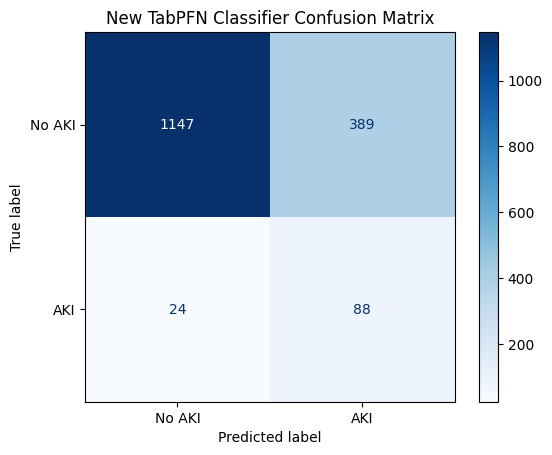

In [13]:
conf_matrix = ConfusionMatrixDisplay.from_predictions(y_test, new_predictions, display_labels=["No AKI", "AKI"], cmap="Blues")
plt.title("New TabPFN Classifier Confusion Matrix")
plt.show()

In [18]:
! pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.1/762.1 kB 24.2 MB/s eta 0:00:00


In [21]:
from tabpfn import TabPFNClassifier
from sklearn.utils.validation import check_is_fitted
from tabpfn.model_loading import save_fitted_tabpfn_model
import joblib

# Your 33 features
X_new = df_new.drop(columns=[target_col])
Y_new = df_new[target_col]

print("Training final TabPFN model...")

tabpfn_model.fit(X_new,Y_new)

# Verify actual TabPFN estimator is fitted
check_is_fitted(tabpfn_model)

print("✅ TabPFN is fitted.")

Training final TabPFN model...
00:00 Fitting... -

00:02 Fitting... Done!
✅ TabPFN is fitted.


In [24]:
print("✅ Fitted TabPFN saved.")

✅ Fitted TabPFN saved.


In [25]:
joblib.dump(
    {
        "threshold": float(best_threshold),
        "features": list(X_new.columns)
    },
    "aki_threshold_config.pkl"
)

print("✅ Threshold configuration saved.")
print("Threshold:", best_threshold)

✅ Threshold configuration saved.
Threshold: 0.44555555555555554


In [15]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import clone
from sklearn.metrics import classification_report, average_precision_score
from sklearn.model_selection import train_test_split

# Train + temp split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation + test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Apply undersampling ONLY to the training data
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

model_undersampled = clone(optimized_tabpfn)
model_undersampled.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on the RAW, UNTOUCHED test set (X_test, not a resampled version)
probs_real = model_undersampled.predict_proba(X_test)[:, 1]
preds_real = (probs_real >= 0.50).astype(int)

resampled_pr_auc = average_precision_score(y_test, probs_real, pos_label=1)

# Reveal TRUE clinical performance
print("--- True Real-World Performance (TabPFN Baseline Model) ---")
print(classification_report(y_test, preds_real))
print(f"Precision Recall Score (AUC): {resampled_pr_auc:.4f}")



00:04 Fitting... Done!
00:03 Predicting... Done!
--- True Real-World Performance (TabPFN Baseline Model) ---
              precision    recall  f1-score   support

           0       0.96      0.69      0.80      1536
           1       0.12      0.57      0.19       112

    accuracy                           0.68      1648
   macro avg       0.54      0.63      0.50      1648
weighted avg       0.90      0.68      0.76      1648

Precision Recall Score (AUC): 0.1789


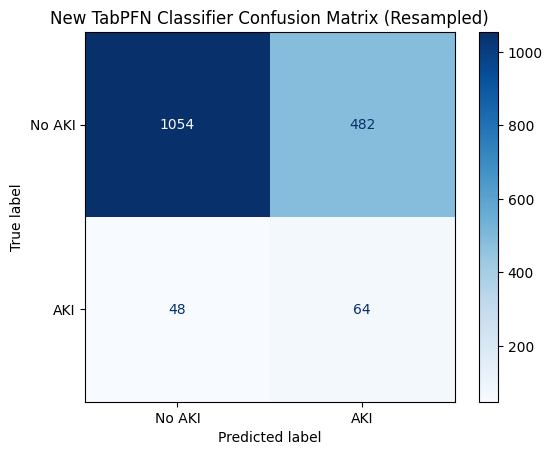

In [ ]:
new_conf_matrix = ConfusionMatrixDisplay.from_predictions(y_test, preds_real, display_labels=["No AKI", "AKI"], cmap="Blues")
plt.title("New TabPFN Classifier Confusion Matrix (Resampled)")
plt.show()

In [ ]:
from itertools import combinations

features = ['Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'NSAIDS', 'SGLT2i', 'Diuretics']

feature_subsets = []

for col in range(1, len(features) + 1):
    for subset in combinations(features, col):
        feature_subsets.append(subset)


print("Number of subsets:", len(feature_subsets))

for i, subset in enumerate(feature_subsets, 1):
    print(i, subset)

Number of subsets: 31
1 ('Elevated Cr or CKD before scan 0N1Y',)
2 ('ACEi/ARB',)
3 ('NSAIDS',)
4 ('SGLT2i',)
5 ('Diuretics',)
6 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB')
7 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS')
8 ('Elevated Cr or CKD before scan 0N1Y', 'SGLT2i')
9 ('Elevated Cr or CKD before scan 0N1Y', 'Diuretics')
10 ('ACEi/ARB', 'NSAIDS')
11 ('ACEi/ARB', 'SGLT2i')
12 ('ACEi/ARB', 'Diuretics')
13 ('NSAIDS', 'SGLT2i')
14 ('NSAIDS', 'Diuretics')
15 ('SGLT2i', 'Diuretics')
16 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'NSAIDS')
17 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'SGLT2i')
18 ('Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'Diuretics')
19 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS', 'SGLT2i')
20 ('Elevated Cr or CKD before scan 0N1Y', 'NSAIDS', 'Diuretics')
21 ('Elevated Cr or CKD before scan 0N1Y', 'SGLT2i', 'Diuretics')
22 ('ACEi/ARB', 'NSAIDS', 'SGLT2i')
23 ('ACEi/ARB', 'NSAIDS', 'Diuretics')
24 ('ACEi/ARB', 'SGLT2i', 'Diureti

There are 31 subsets as one of the subsets consists of pure zero values (0,0,0,0,0) in the 5 features, hence why the combination is dropped.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, fbeta_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from tabpfn_client import TabPFNClassifier


# Define the 5 features
features_5 = ['Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'Diuretics', 'NSAIDS', 'SGLT2i']

# Generate all non-empty combinations of these 5 features
feature_subsets_5 = []
for r in range(1, len(features_5) + 1):
    for combination in combinations(features_5, r):
        feature_subsets_5.append(list(combination))

print(f"Number of feature combinations: {len(feature_subsets_5)}")

results_5 = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterate through each feature subset
for selected_features in feature_subsets_5:
    print(f"\nEvaluating with features (via 5-fold CV): {selected_features}")

    # Prepare data for cross-validation
    X_cv = X_train[selected_features]
    y_cv = y_train


    base_tabpfn_for_cv = optimized_tabpfn

    # Fit the model on the cross-validation data
    base_tabpfn_for_cv.fit(X_cv, y_cv)

    # Perform cross-validated prediction to get probabilities
    # y_probas_cv will contain the predicted probabilities for each fold's test set
    y_probas_cv = cross_val_predict(
        base_tabpfn_for_cv,
        X_cv,
        y_cv,
        cv=skf,
        method='predict_proba',
        n_jobs=-1 # Use all available cores for parallel processing
    )

    # Extract probabilities for the positive class
    positive_probs_cv = y_probas_cv[:, 1]

    # Find the optimal threshold for F2 score on the cross-validated predictions
    best_threshold_cv = 0.5
    best_f2_score_cv = -1.0 # Initialize with a value lower than any possible F2 score

    # Iterate through potential thresholds
    for threshold_val in np.linspace(0.01, 0.99, 100):
        current_preds_cv = (positive_probs_cv >= threshold_val).astype(int)

        # Calculate F2 score (beta=2 gives recall twice as much importance as precision)
        current_f2_cv = fbeta_score(y_cv, current_preds_cv, beta=2, zero_division=0)

        if current_f2_cv > best_f2_score_cv:
            best_f2_score_cv = current_f2_cv
            best_threshold_cv = threshold_val

    # Calculate other metrics using the optimized threshold
    y_pred_cv_optimized = (positive_probs_cv >= best_threshold_cv).astype(int)

    precision_cv = precision_score(y_cv, y_pred_cv_optimized, zero_division=0)
    recall_cv = recall_score(y_cv, y_pred_cv_optimized, zero_division=0)
    f1_cv = f1_score(y_cv, y_pred_cv_optimized, zero_division=0)
    pr_auc_cv = average_precision_score(y_cv, positive_probs_cv) # PR-AUC uses probabilities directly

    # Store results
    results_5.append({
        'Features': ' + '.join(selected_features),
        'Number of Features': len(selected_features),
        'CV Optimized Threshold': f'{best_threshold_cv:.2f}', # Store threshold
        'CV F2 Score': f'{best_f2_score_cv:.4f}', # Store best F2 score from CV
        'CV Precision': f'{precision_cv:.4f}',
        'CV Recall': f'{recall_cv:.4f}',
        'CV F1 Score': f'{f1_cv:.4f}',
        'CV PR AUC': f'{pr_auc_cv:.4f}'
    })

# Convert results to DataFrame and sort
results_df_5 = pd.DataFrame(results_5)
results_df_5 = results_df_5.sort_values(by='CV F2 Score', ascending=False) # Sort by CV F2 score

print("\n--- Cross-Validation Results for 5-feature subsets (Sorted by CV F2 Score) ---")
print(results_df_5)

Number of feature combinations: 31

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y']
00:00 Fitting... \

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['ACEi/ARB']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Diuretics']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['NSAIDS']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['SGLT2i']
00:00 Fitting... |

...

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'NSAIDS', 'SGLT2i']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'Diuretics', 'NSAIDS', 'SGLT2i']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['ACEi/ARB', 'Diuretics', 'NSAIDS', 'SGLT2i']
00:00 Fitting... /

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'ACEi/ARB', 'Diuretics', 'NSAIDS', 'SGLT2i']
00:00 Fitting... |

00:02 Fitting... Done!

--- Cross-Validation Results for 5-feature subsets (Sorted by CV F2 Score) ---
                                             Features  Number of Features  \
19  Elevated Cr or CKD before scan 0N1Y + Diuretic...                   3   
28  Elevated Cr or CKD before scan 0N1Y + Diuretic...                   4   
15  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB...                   3   
18  Elevated Cr or CKD before scan 0N1Y + Diuretic...                   3   
26  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB...                   4   
25  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB...                   4   
6     Elevated Cr or CKD before scan 0N1Y + Diuretics                   2   
30  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB...                   5   
27  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB...                   4   
5      Elevated Cr or CKD before scan 0N1Y + ACEi/ARB                   2   
16  Elevated Cr or CKD before scan 0N1Y + ACEi/ARB

In [ ]:
# Retrieve the top 3 CV score and PR-AUC of features

top_3_cv_scores = results_df_5.head(3)
top_3_pr_aucs = results_df_5.head(3)

# Display every row in the dataset
pd.set_option('display.max_rows', None)

# Display every column in the dataset
pd.set_option('display.max_columns', None)

# Show the full text content inside each cell without clipping
pd.set_option('display.max_colwidth', None)

# Prevent the layout from wrapping lines horizontally
pd.set_option('display.width', None)

print("\n--- Top 5 CV Scores (Sorted by CV F2 Score) ---")
print(top_3_cv_scores)

print("\n--- Top 5 PR-AUC Scores (Sorted by CV F2 Score) ---")
print(top_3_pr_aucs)




--- Top 5 CV Scores (Sorted by CV F2 Score) ---
                                                             Features  \
19           Elevated Cr or CKD before scan 0N1Y + Diuretics + SGLT2i   
28  Elevated Cr or CKD before scan 0N1Y + Diuretics + NSAIDS + SGLT2i   
15         Elevated Cr or CKD before scan 0N1Y + ACEi/ARB + Diuretics   

    Number of Features CV Optimized Threshold CV F2 Score CV Precision  \
19                   3                   0.51      0.3331       0.1319   
28                   4                   0.51      0.3327       0.1335   
15                   3                   0.43      0.3321       0.1303   

   CV Recall CV F1 Score CV PR AUC  
19    0.5386      0.2119    0.1051  
28    0.5308      0.2133    0.1054  
15    0.5420      0.2101    0.1087  

--- Top 5 PR-AUC Scores (Sorted by CV F2 Score) ---
                                                             Features  \
19           Elevated Cr or CKD before scan 0N1Y + Diuretics + SGLT2i   
28  Elevated C

In [ ]:
selected_features = ["Elevated Cr or CKD before scan 0N1Y","Diuretics","SGLT2i"] # 3 features from row 19

# Subset full training dataset (X_train contains all samples)
X_train_final = X_train[selected_features]

final_model = optimized_tabpfn

# Train on 100% of training data
final_model.fit(X_train_final, y_train)

OPTIMAL_THRESHOLD = 0.51 # Value extracted from table

00:00 Fitting... /

00:02 Fitting... Done!


In [ ]:
X_test_final = X_test[selected_features]

# Generate raw, balanced risk probabilities
# Column 1 represents the probability of the positive class (the event)
probabilities = final_model.predict_proba(X_test_final)[:, 1]

# Apply optimal F2 threshold (0.51) to generate binary alerts
final_predictions = (probabilities >= OPTIMAL_THRESHOLD).astype(int)


00:00 Predicting... \

00:03 Predicting... Done!


Cross-validation precision and recall determines how well the model performs on unseen data across the stratified folds.

Selected Feature Confusion Matrix
              precision    recall  f1-score   support

           0       0.95      0.73      0.83      1536
           1       0.12      0.52      0.20       112

    accuracy                           0.72      1648
   macro avg       0.54      0.63      0.51      1648
weighted avg       0.90      0.72      0.79      1648



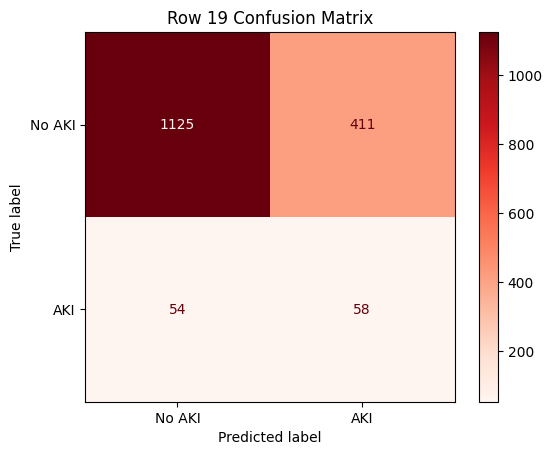

In [ ]:
print('Selected Feature Confusion Matrix')
print(classification_report(y_test, final_predictions))

selected_conf_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, final_predictions), display_labels=["No AKI", "AKI"])
print(selected_conf_matrix.plot(cmap='Reds'))
plt.title('Row 19 Confusion Matrix')
plt.show()

In [ ]:
from sklearn.base import clone


print("==== Training & Evaluating: Row_28_Model ====")


features_28 = ["Elevated Cr or CKD before scan 0N1Y", "NSAIDS", "Diuretics", "SGLT2i"] # 4 features from row 28
X_train_28 = X_train[features_28]
X_test_28 = X_test[features_28]


model_28 = clone(optimized_tabpfn)
model_28.fit(X_train_28, y_train)

# Predict and Apply 0.51 Threshold
probs_28 = model_28.predict_proba(X_test_28)[:, 1]
preds_28 = (probs_28 >= 0.51).astype(int)

report_28 = classification_report(y_test, preds_28)
print(report_28)


==== Training & Evaluating: Row_28_Model ====
00:00 Fitting... \

00:02 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1536
           1       0.13      0.51      0.20       112

    accuracy                           0.73      1648
   macro avg       0.54      0.63      0.52      1648
weighted avg       0.90      0.73      0.79      1648



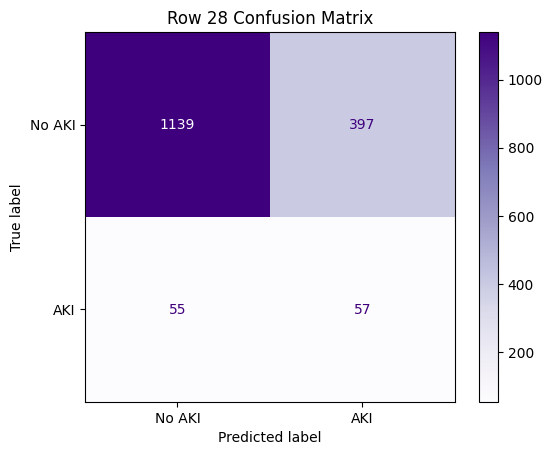

In [ ]:
matrix_28 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, preds_28), display_labels=["No AKI", "AKI"])
print(matrix_28.plot(cmap='Purples'))
plt.title('Row 28 Confusion Matrix')
plt.show()

In [ ]:
print("\n==== Training & Evaluating: Row_15_Model ====")

features_15 = ["Elevated Cr or CKD before scan 0N1Y", "ACEi/ARB", "Diuretics"] # 3 features from row 15
X_train_15 = X_train[features_15]
X_test_15 = X_test[features_15]


model_15 = clone(optimized_tabpfn)
model_15.fit(X_train_15, y_train)

# Predict and Apply 0.43 Threshold
probs_15 = model_15.predict_proba(X_test_15)[:, 1]
preds_15 = (probs_15 >= 0.43).astype(int)

# 4. Generate & Store Independent Results
report_15 = classification_report(y_test, preds_15)
print(report_15)


==== Training & Evaluating: Row_15_Model ====
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
              precision    recall  f1-score   support

           0       0.96      0.73      0.82      1536
           1       0.12      0.54      0.20       112

    accuracy                           0.71      1648
   macro avg       0.54      0.63      0.51      1648
weighted avg       0.90      0.71      0.78      1648



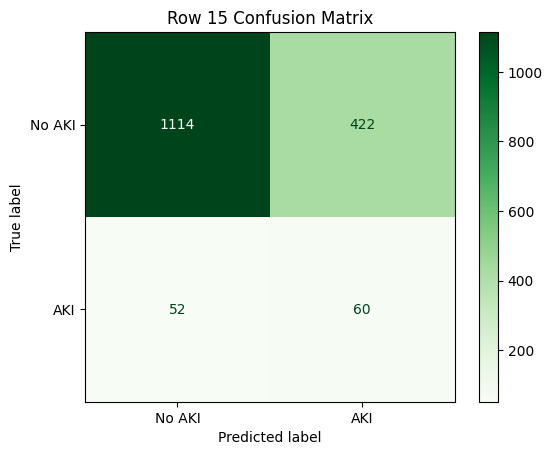

In [ ]:
matrix_15 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, preds_15), display_labels=["No AKI", "AKI"])
matrix_15.plot(cmap='Greens')
plt.title('Row 15 Confusion Matrix')
plt.show()

In [ ]:

features = ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1',
            'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']

feature_subsets = []

for col in range(1, len(features) + 1):
    for subset in combinations(features, col):
        feature_subsets.append(subset)


print("Number of subsets:", len(feature_subsets))

for i, subset in enumerate(feature_subsets, 1):
    print(i, subset)

Number of subsets: 63
1 ('Elevated Cr or CKD before scan 0N1Y',)
2 ('DM code, no DM-0, DM-1',)
3 ('Calculated baseline creatinine',)
4 ('HTN code, no HTN-0, HTN-1',)
5 ('Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1',)
6 ('HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)',)
7 ('Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1')
8 ('Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine')
9 ('Elevated Cr or CKD before scan 0N1Y', 'HTN code, no HTN-0, HTN-1')
10 ('Elevated Cr or CKD before scan 0N1Y', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1')
11 ('Elevated Cr or CKD before scan 0N1Y', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)')
12 ('DM code, no DM-0, DM-1', 'Calculated baseline creatinine')
13 ('DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1')
14 ('DM code, no DM-0, DM-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1')
15 ('DM code, no DM-0, DM-1', 'HCT low=2, normal=1, high= 3, nd

In [ ]:
second_features_5 = ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1',
            'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']


# Generate all non-empty combinations of these 5 features
second_feature_subsets_5 = []
for r in range(1, len(second_features_5) + 1):
    for combination in combinations(second_features_5, r):
        second_feature_subsets_5.append(list(combination))

print(f"Number of feature combinations: {len(second_feature_subsets_5)}")

# Prepare to store results
second_results_5 = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterate through each feature subset
for selected_features in second_feature_subsets_5:
    print(f"\nEvaluating with features (via 5-fold CV): {selected_features}")

    # Prepare data for cross-validation
    X_cv = X_train[selected_features]
    y_cv = y_train


    base_tabpfn_for_cv = optimized_tabpfn

    # Fit the model on the cross-validation data
    base_tabpfn_for_cv.fit(X_cv, y_cv)

    # Perform cross-validated prediction to get probabilities
    # y_probas_cv will contain the predicted probabilities for each fold's test set
    y_probas_cv = cross_val_predict(
        base_tabpfn_for_cv,
        X_cv,
        y_cv,
        cv=skf,
        method='predict_proba',
        n_jobs=-1 # Use all available cores for parallel processing
    )

    # Extract probabilities for the positive class
    positive_probs_cv = y_probas_cv[:, 1]

    # Find the optimal threshold for F2 score on the cross-validated predictions
    best_threshold_cv = 0.5
    best_f2_score_cv = -1.0 # Initialize with a value lower than any possible F2 score

    # Iterate through potential thresholds
    for threshold_val in np.linspace(0.01, 0.99, 100):
        current_preds_cv = (positive_probs_cv >= threshold_val).astype(int)
        # Calculate F2 score (beta=2 gives recall twice as much importance as precision)
        current_f2_cv = fbeta_score(y_cv, current_preds_cv, beta=2, zero_division=0)

        if current_f2_cv > best_f2_score_cv:
            best_f2_score_cv = current_f2_cv
            best_threshold_cv = threshold_val


    y_pred_cv_optimized = (positive_probs_cv >= best_threshold_cv).astype(int)

    precision_cv = precision_score(y_cv, y_pred_cv_optimized, zero_division=0)
    recall_cv = recall_score(y_cv, y_pred_cv_optimized, zero_division=0)
    f1_cv = f1_score(y_cv, y_pred_cv_optimized, zero_division=0)
    pr_auc_cv = average_precision_score(y_cv, positive_probs_cv) # PR-AUC uses probabilities directly

    # Store results
    second_results_5.append({
        'Features': ' + '.join(selected_features),
        'Number of Features': len(selected_features),
        'CV Optimized Threshold': f'{best_threshold_cv:.2f}', # Store threshold
        'CV F2 Score': f'{best_f2_score_cv:.4f}', # Store best F2 score from CV
        'CV Precision': f'{precision_cv:.4f}',
        'CV Recall': f'{recall_cv:.4f}',
        'CV F1 Score': f'{f1_cv:.4f}',
        'CV PR AUC': f'{pr_auc_cv:.4f}'
    })

# Convert results to DataFrame and sort
second_results_df_5 = pd.DataFrame(second_results_5)
second_results_df_5 = second_results_df_5.sort_values(by='CV F2 Score', ascending=False) # Sort by CV F2 score

Number of feature combinations: 63

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Calculated baseline creatinine']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['HTN code, no HTN-0, HTN-1']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1']
00:00 Fitting... |

...

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1']
00:05 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:05 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:00 Fitting... |

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:05 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1']
00:05 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT 

00:02 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!

Evaluating with features (via 5-fold CV): ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1', 'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']
00:03 Fitting... Done!


In [ ]:
print("\n--- Cross-Validation Results for 5-feature subsets (Sorted by CV F2 Score) ---")
print(second_results_df_5)



--- Cross-Validation Results for 5-feature subsets (Sorted by CV F2 Score) ---
                                                                                                                                                                                                                                            Features  \
60                           Elevated Cr or CKD before scan 0N1Y + Calculated baseline creatinine + HTN code, no HTN-0, HTN-1 + Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1 + HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)   
47                                                                                Elevated Cr or CKD before scan 0N1Y + Calculated baseline creatinine + HTN code, no HTN-0, HTN-1 + Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1   
58                              Elevated Cr or CKD before scan 0N1Y + DM code, no DM-0, DM-1 + Calculated baseline creatinine + Cardiovascular disease (PVD or IHD or CVA): Abse

In [ ]:
# Retrieve the top 3 CV score and PR-AUC of features

second_top_3_cv_scores = second_results_df_5.head(3)
second_top_3_pr_aucs = second_results_df_5.head(3)

# Display every row in the dataset
pd.set_option('display.max_rows', None)

# Display every column in the dataset
pd.set_option('display.max_columns', None)

# Show the full text content inside each cell without clipping
pd.set_option('display.max_colwidth', None)

# Prevent the layout from wrapping lines horizontally
pd.set_option('display.width', None)

print("\n--- Top 5 CV Scores (Sorted by CV F2 Score) ---")
print(second_top_3_cv_scores)

print("\n--- Top 5 PR-AUC Scores (Sorted by CV F2 Score) ---")
print(second_top_3_pr_aucs)


--- Top 5 CV Scores (Sorted by CV F2 Score) ---
                                                                                                                                                                                                                   Features  \
60  Elevated Cr or CKD before scan 0N1Y + Calculated baseline creatinine + HTN code, no HTN-0, HTN-1 + Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1 + HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)   
47                                                       Elevated Cr or CKD before scan 0N1Y + Calculated baseline creatinine + HTN code, no HTN-0, HTN-1 + Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1   
58     Elevated Cr or CKD before scan 0N1Y + DM code, no DM-0, DM-1 + Calculated baseline creatinine + Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1 + HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)   

    Number of Features CV Optimized Threshold CV F2 Score 

In [ ]:

# Extract the 5 features for training

second_selected_features = ['Elevated Cr or CKD before scan 0N1Y', 'Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1',
                            'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']

# Subset full training dataset (X_train contains all samples)
X_train_final = X_train[selected_features]

final_model = optimized_tabpfn

# Train on 100% of training data
final_model.fit(X_train_final, y_train)

SECOND_OPTIMAL_THRESHOLD = 0.43

00:00 Fitting... |

00:02 Fitting... Done!


In [ ]:
X_test_final = X_test[selected_features]

# Generate raw, balanced risk probabilities
# Column 1 represents the probability of the positive class (the event)
second_probabilities = final_model.predict_proba(X_test_final)[:, 1]

# Apply optimal F2 threshold (0.51) to generate binary alerts
second_final_predictions = (second_probabilities >= SECOND_OPTIMAL_THRESHOLD).astype(int)


00:00 Predicting... |

00:04 Predicting... Done!


2nd Selected Feature Confusion Matrix
              precision    recall  f1-score   support

           0       0.96      0.73      0.82      1536
           1       0.12      0.54      0.20       112

    accuracy                           0.71      1648
   macro avg       0.54      0.63      0.51      1648
weighted avg       0.90      0.71      0.78      1648



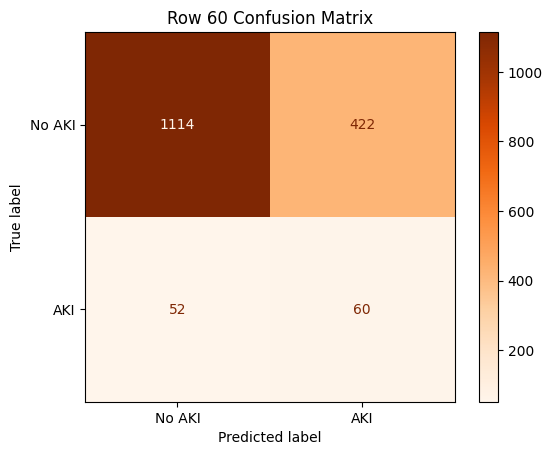

In [ ]:
print('2nd Selected Feature Confusion Matrix')
print(classification_report(y_test, second_final_predictions))

selected_conf_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, second_final_predictions), display_labels=["No AKI", "AKI"])
print(selected_conf_matrix.plot(cmap='Oranges'))
plt.title('Row 60 Confusion Matrix')
plt.show()

In [ ]:
print("==== Training & Evaluating: Row_47_Model ====")

# Extract the 4 features for training

features_47 = ['Elevated Cr or CKD before scan 0N1Y','Calculated baseline creatinine', 'HTN code, no HTN-0, HTN-1','Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1']

X_train_47 = X_train[features_47]
X_test_47 = X_test[features_47]


model_47 = clone(optimized_tabpfn)
model_47.fit(X_train_47, y_train)

# Predict and Apply 0.51 Threshold
probs_47 = model_47.predict_proba(X_test_47)[:, 1]
preds_47 = (probs_47 >= 0.45).astype(int) # value extracted from feature evaluation table

report_47 = classification_report(y_test, preds_47)
print(report_47)

==== Training & Evaluating: Row_47_Model ====
00:00 Fitting... |

00:02 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      1536
           1       0.12      0.46      0.19       112

    accuracy                           0.73      1648
   macro avg       0.53      0.60      0.51      1648
weighted avg       0.89      0.73      0.79      1648



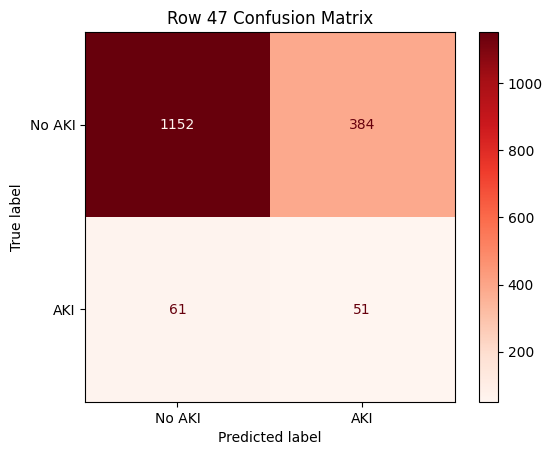

In [ ]:
matrix_47 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, preds_47), display_labels=["No AKI", "AKI"])
matrix_47.plot(cmap='Reds')
plt.title('Row 47 Confusion Matrix')
plt.show()

In [ ]:
print("==== Training & Evaluating: Row_58_Model ====")

# Extract the 5 features for training

features_58 = ['Elevated Cr or CKD before scan 0N1Y', 'DM code, no DM-0, DM-1','Calculated baseline creatinine',
               'Cardiovascular disease (PVD or IHD or CVA): Absent-0, Present-1', 'HCT low=2, normal=1, high= 3, nd-9 (normal 38-52%)']

X_train_58 = X_train[features_58]
X_test_58 = X_test[features_58]


model_58 = clone(optimized_tabpfn)
model_58.fit(X_train_58, y_train)

probs_58 = model_58.predict_proba(X_test_58)[:, 1]
preds_58 = (probs_58 >= 0.46).astype(int) # value extracted from feature evaluation table

report_58 = classification_report(y_test, preds_58)
print(report_58)

==== Training & Evaluating: Row_58_Model ====
00:00 Fitting... \

00:02 Fitting... Done!
00:03 Predicting... Done!
              precision    recall  f1-score   support

           0       0.95      0.77      0.85      1536
           1       0.12      0.44      0.19       112

    accuracy                           0.75      1648
   macro avg       0.54      0.60      0.52      1648
weighted avg       0.89      0.75      0.81      1648



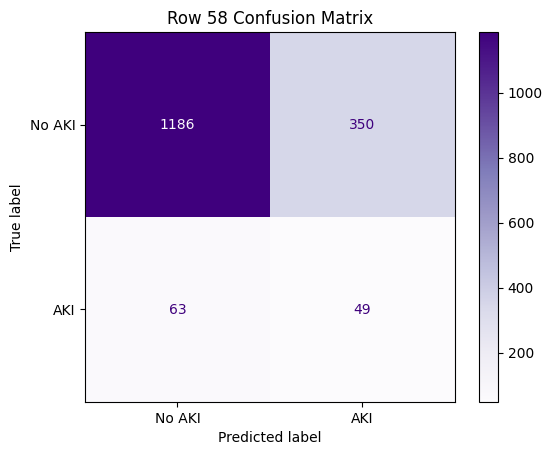

In [ ]:
matrix_58 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, preds_58), display_labels=["No AKI", "AKI"])
matrix_58.plot(cmap='Purples')
plt.title('Row 58 Confusion Matrix')
plt.show()